In [2]:
# ============================================================
# 2-unit RAMMs / Maxwell-style Hamiltonian + Hessian
# Node-based linearized formulation:
#
#   l = C u
#   H = 1/2 * l^T K l = 1/2 * u^T C^T K C u
#
# ------------------------------------------------------------
# HOW TO USE
# 1) Edit `nodes` to match your 2-unit geometry at the reference state
# 2) Edit `bonds` to include the active constraints you want
# 3) Edit `k_vals` for the corresponding stiffnesses
#
# Each node is 2D: (y, z)
# Each displacement block is [u_{iy}, u_{iz}]
# ============================================================

In [11]:
# import libraries
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display # for printing things in LaTex

In [43]:
# --------------------------------------------------------------------------
# 1. VERSION 1: Define symbolic node coordinates for the REFERENCE geometry
# --------------------------------------------------------------------------
'''
y0B, z0B = sp.symbols('y0B z0B', real=True) # unit 0 bottom coordinate
y0L, z0L = sp.symbols('y0L z0L', real=True) # unit 0 left coordinate
y0R, z0R = sp.symbols('y0R z0R', real=True) # unit 0 right coordinate
y0T, z0T = sp.symbols('y0T z0T', real=True) # unit 0 top coordinate

y1B, z1B = sp.symbols('y1B z1B', real=True) # unit 1 bottom coordinate
y1L, z1L = sp.symbols('y1L z1L', real=True) # unit 1 left coordinate
y1R, z1R = sp.symbols('y1R z1R', real=True) # unit 1 right coordinate
y1T, z1T = sp.symbols('y1T z1T', real=True) # unit 1 top coordinate

# sp.Matrix allows us to work with symbolic expressions
# ("does algebra; does not store numbers")
nodes = [
    sp.Matrix([y0B, z0B]), # node 0
    sp.Matrix([y0L, z0L]), # node 1
    sp.Matrix([y0R, z0R]), # node 2
    sp.Matrix([y0T, z0T]), # node 3
    sp.Matrix([y1B, z1B]), # node 4
    sp.Matrix([y1L, z1L]), # node 5
    sp.Matrix([y1R, z1R]), # node 6
    sp.Matrix([y1T, z1T]), # node 7
]
'''
# --------------------------------------------------------------------
# 1. VERSION 2: Define reduced coordinates q and geometric parameters
# --------------------------------------------------------------------

theta0, z0, z1 = sp.symbols('theta0 z0 z1', real=True)
q = sp.Matrix([theta0, z0, z1])

# geometric parameters
a0, b0 = sp.symbols('a0 b0', positive=True, real=True)   # half-width / half-height of unit 0
a1, b1 = sp.symbols('a1 b1', positive=True, real=True)   # half-width / half-height of unit 1
eps_bpg = sp.symbols('eps_bpg', real=True)               # contact gap / offset

# define the dimension
dim = 2          # 2D
print("dimensions:", dim)

dimensions: 2


In [44]:
# ------------------------------------------------------------
# 2. VERSION 2: Define node positions as functions of q
# ------------------------------------------------------------

def rot(theta):
    return sp.Matrix([
        [sp.cos(theta), -sp.sin(theta)],
        [sp.sin(theta),  sp.cos(theta)]
    ])

# local reference coordinates for unit 0
pB0_local = sp.Matrix([0, 0])
pL0_local = sp.Matrix([-a0, b0])
pR0_local = sp.Matrix([ a0, b0])
pT0_local = sp.Matrix([0,  2*b0])

# local reference coordinates for unit 1
pB1_local = sp.Matrix([0, 0])
pL1_local = sp.Matrix([-a1, b1])
pR1_local = sp.Matrix([ a1, b1])
pT1_local = sp.Matrix([0,  2*b1])

# global anchors
c0 = sp.Matrix([0, z0])
c1 = sp.Matrix([0, z1])

R0 = rot(theta0)
R1 = rot(theta0)   # replace if unit 1 has its own angle

p0B = c0 + R0 * pB0_local
p0L = c0 + R0 * pL0_local
p0R = c0 + R0 * pR0_local
p0T = c0 + R0 * pT0_local

p1B = c1 + R1 * pB1_local
p1L = c1 + R1 * pL1_local
p1R = c1 + R1 * pR1_local
p1T = c1 + R1 * pT1_local

nodes = [
    p0B,  # 0
    p0L,  # 1
    p0R,  # 2
    p0T,  # 3
    p1B,  # 4
    p1L,  # 5
    p1R,  # 6
    p1T,  # 7
]
print("total nodes:", len(nodes))

total nodes: 8


In [17]:
# ------------------------------------------------------------
# 2. REMOVE: (this is for VERSION 1) Define the displacement vector u
# ------------------------------------------------------------
#
# u = [u0y, u0z, u1y, u1z, ..., u5y, u5z]^T
'''
N = len(nodes)   # number of nodes

u_symbols = []
for i in range(N):
    uiy, uiz = sp.symbols(f'u{i}y u{i}z', real=True)
    u_symbols.extend([uiy, uiz])

u = sp.Matrix(u_symbols)  # shape = (2N, 1)
print("should be #dim x #nodes")
print("u shape:", u.shape)
'''

'\nN = len(nodes)   # number of nodes\n\nu_symbols = []\nfor i in range(N):\n    uiy, uiz = sp.symbols(f\'u{i}y u{i}z\', real=True)\n    u_symbols.extend([uiy, uiz])\n\nu = sp.Matrix(u_symbols)  # shape = (2N, 1)\nprint("should be #dim x #nodes")\nprint("u shape:", u.shape)\n'

In [45]:
# ------------------------------------------------------------
# 3. Define the active bonds / constraints
# ------------------------------------------------------------
#
# Each tuple (i, j) means a linearized central-force constraint
# between node i and node j (something connecting i and j that 
# depends on distance).
#
# IMPORTANT:
# - If you're modeling the rigid bars of each diamond, include those here
# - If you're modeling only active contacts, include only those here
# - If you want different states (free/jammed), use different bond lists
#
# Example placeholder list:
#   lower diamond edges, upper diamond edges, and one inter-unit link

shape_bonds = [
    # -------------------------
    # UNIT 0 (lower diamond)
    # -------------------------

    (0, 1),  # bottom → left   (p0B to p0L)
    (1, 3),  # left   → top    (p0L to p0T)
    (3, 2),  # top    → right  (p0T to p0R)
    (2, 0),  # right  → bottom (p0R to p0B)

    # -------------------------
    # UNIT 1 (upper diamond)
    # -------------------------

    (4, 5),  # bottom → left   (p1B to p1L)
    (5, 7),  # left   → top    (p1L to p1T)
    (7, 6),  # top    → right  (p1T to p1R)
    (6, 4),  # right  → bottom (p1R to p1B)

    # -------------------------
    # INTERNAL SHAPE (height)
    # -------------------------

    (0, 3),  # bottom → top, unit 0 (p0B to p0T)
    (4, 7),  # bottom → top, unit 1 (p1B to p1T)
]

def distance_constraint(pa, pb, L0):
    return sp.sqrt(((pb - pa).T * (pb - pa))[0]) - L0

RLs = sp.symbols(f'RL0:{len(shape_bonds)}', positive=True, real=True)

l_shape = sp.Matrix([
    distance_constraint(nodes[i], nodes[j], RLs[k])
    for k, (i, j) in enumerate(shape_bonds)
])
print("bonds:", len(shape_bonds))

bonds: 10


In [46]:
# ------------------------------------------------------------
# 4. Explicit contact / kinematic constraints
# ------------------------------------------------------------
l_constraint = sp.Matrix([
    theta0 - (sp.pi/4) * sp.sin(2 * sp.pi * z1)**2,
    z1 - (z0 - eps_bpg),
    z0 - z1
])

In [47]:
# ------------------------------------------------------------
# 5. Full constraint vector
# ------------------------------------------------------------
l = sp.Matrix.vstack(l_shape, l_constraint)

In [48]:
# ------------------------------------------------------------
# 6. Compatibility matrix
# ------------------------------------------------------------
C = l.jacobian(q)

In [49]:
# ------------------------------------------------------------
# 7. Stiffness matrix
# ------------------------------------------------------------
k_vals = sp.symbols(f'k0:{l.shape[0]}', positive=True, real=True)
K = sp.diag(*k_vals)

print("q shape:", q.shape)
print("l shape:", l.shape)
print("C shape:", C.shape)
print("K shape:", K.shape)

print("l:")
display(l)
print("C:")
display(C)
print("K:")
display(K)

q shape: (3, 1)
l shape: (13, 1)
C shape: (13, 3)
K shape: (13, 13)
l:


Matrix([
[-RL0 + sqrt((-a0*sin(theta0) + b0*cos(theta0))**2 + (-a0*cos(theta0) - b0*sin(theta0))**2)],
[  -RL1 + sqrt((a0*sin(theta0) + b0*cos(theta0))**2 + (a0*cos(theta0) - b0*sin(theta0))**2)],
[  -RL2 + sqrt((a0*sin(theta0) - b0*cos(theta0))**2 + (a0*cos(theta0) + b0*sin(theta0))**2)],
[-RL3 + sqrt((-a0*sin(theta0) - b0*cos(theta0))**2 + (-a0*cos(theta0) + b0*sin(theta0))**2)],
[-RL4 + sqrt((-a1*sin(theta0) + b1*cos(theta0))**2 + (-a1*cos(theta0) - b1*sin(theta0))**2)],
[  -RL5 + sqrt((a1*sin(theta0) + b1*cos(theta0))**2 + (a1*cos(theta0) - b1*sin(theta0))**2)],
[  -RL6 + sqrt((a1*sin(theta0) - b1*cos(theta0))**2 + (a1*cos(theta0) + b1*sin(theta0))**2)],
[-RL7 + sqrt((-a1*sin(theta0) - b1*cos(theta0))**2 + (-a1*cos(theta0) + b1*sin(theta0))**2)],
[                              -RL8 + sqrt(4*b0**2*sin(theta0)**2 + 4*b0**2*cos(theta0)**2)],
[                              -RL9 + sqrt(4*b1**2*sin(theta0)**2 + 4*b1**2*cos(theta0)**2)],
[                                                  

C:


Matrix([
[((-a0*sin(theta0) + b0*cos(theta0))*(-2*a0*cos(theta0) - 2*b0*sin(theta0))/2 + (2*a0*sin(theta0) - 2*b0*cos(theta0))*(-a0*cos(theta0) - b0*sin(theta0))/2)/sqrt((-a0*sin(theta0) + b0*cos(theta0))**2 + (-a0*cos(theta0) - b0*sin(theta0))**2),  0,                                0],
[    ((-2*a0*sin(theta0) - 2*b0*cos(theta0))*(a0*cos(theta0) - b0*sin(theta0))/2 + (a0*sin(theta0) + b0*cos(theta0))*(2*a0*cos(theta0) - 2*b0*sin(theta0))/2)/sqrt((a0*sin(theta0) + b0*cos(theta0))**2 + (a0*cos(theta0) - b0*sin(theta0))**2),  0,                                0],
[    ((-2*a0*sin(theta0) + 2*b0*cos(theta0))*(a0*cos(theta0) + b0*sin(theta0))/2 + (a0*sin(theta0) - b0*cos(theta0))*(2*a0*cos(theta0) + 2*b0*sin(theta0))/2)/sqrt((a0*sin(theta0) - b0*cos(theta0))**2 + (a0*cos(theta0) + b0*sin(theta0))**2),  0,                                0],
[((-a0*sin(theta0) - b0*cos(theta0))*(-2*a0*cos(theta0) + 2*b0*sin(theta0))/2 + (2*a0*sin(theta0) + 2*b0*cos(theta0))*(-a0*cos(theta0) + b0*sin(theta0)

K:


Matrix([
[k0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0],
[ 0, k1,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0],
[ 0,  0, k2,  0,  0,  0,  0,  0,  0,  0,   0,   0,   0],
[ 0,  0,  0, k3,  0,  0,  0,  0,  0,  0,   0,   0,   0],
[ 0,  0,  0,  0, k4,  0,  0,  0,  0,  0,   0,   0,   0],
[ 0,  0,  0,  0,  0, k5,  0,  0,  0,  0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0, k6,  0,  0,  0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0, k7,  0,  0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0, k8,  0,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0, k9,   0,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, k10,   0,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0, k11,   0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,   0,   0, k12]])

In [50]:
# is l redundant (repeated constraints)
for i, expr in enumerate(l_shape):
    print(i, sp.simplify(expr))

0 -RL0 + sqrt(a0**2 + b0**2)
1 -RL1 + sqrt(a0**2 + b0**2)
2 -RL2 + sqrt(a0**2 + b0**2)
3 -RL3 + sqrt(a0**2 + b0**2)
4 -RL4 + sqrt(a1**2 + b1**2)
5 -RL5 + sqrt(a1**2 + b1**2)
6 -RL6 + sqrt(a1**2 + b1**2)
7 -RL7 + sqrt(a1**2 + b1**2)
8 -RL8 + 2*b0
9 -RL9 + 2*b1


In [ ]:
# ------------------------------------------------------------
# REMOVE (VERSION 1 Stuff)  Define bond stiffnesses
# ------------------------------------------------------------
#
# One stiffness per bond/constraint.
# Can make them all the same or symbolic.
'''
k_vals = sp.symbols(f'k0:{len(shape_bonds)}', positive=True, real=True)
K = sp.diag(*k_vals)
print("K shape:", K.shape)
print("K matrix:")
display(K)
'''

K shape: (8, 8)
K matrix:


Matrix([
[k0,  0,  0,  0,  0,  0,  0,  0],
[ 0, k1,  0,  0,  0,  0,  0,  0],
[ 0,  0, k2,  0,  0,  0,  0,  0],
[ 0,  0,  0, k3,  0,  0,  0,  0],
[ 0,  0,  0,  0, k4,  0,  0,  0],
[ 0,  0,  0,  0,  0, k5,  0,  0],
[ 0,  0,  0,  0,  0,  0, k6,  0],
[ 0,  0,  0,  0,  0,  0,  0, k7]])

In [ ]:
# ------------------------------------------------------------
# REMOVE (VERSION 1 Stuff) Build the compatibility matrix C
# ------------------------------------------------------------
#
# For bond alpha = (i, j), the linearized extension is:
#
#   l_alpha = n_ij^T (u_j - u_i)
#
# where n_ij is the unit vector along the reference bond.
#
# This gives one row of C.
'''
def compatibility_row(i, j, nodes, N):
    xi = nodes[i]
    xj = nodes[j]

    d = xj - xi
    L = sp.sqrt((d.T * d)[0])        # bond length
    n = d / L                        # unit direction vector (2x1)

    row = sp.zeros(1, 2 * N)

    # moving in the direction i or j moves bonds further or closer together
    # (hence one is negative, the other is positive)
    # TODO: need a visual for this
    # place -n^T in node i columns
    row[0, 2*i]   = -n[0]
    row[0, 2*i+1] = -n[1]

    # place +n^T in node j columns
    row[0, 2*j]   =  n[0]
    row[0, 2*j+1] =  n[1]
    
    # simplify takes too long to run in the Hamiltonian, so remove it for now
    #return sp.simplify(row)
    return sp.simplify(row)

C_rows = [compatibility_row(i, j, nodes, N) for (i, j) in shape_bonds]
C = sp.Matrix.vstack(*C_rows)
print("C matrix shape:", C.shape)
print("C matrix:")
display(C)
'''

C matrix shape: (8, 16)
C matrix:


Matrix([
[(y0B - y0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2), (z0B - z0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2), (-y0B + y0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2), (-z0B + z0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2),                                                  0,                                                  0,                                                  0,                                                  0,                                                 0,                                                 0,                                                  0,                                                  0,                                                  0,                                                  0,                                                  0,                                                  0],
[                                                0,                                                 0,  (y0L - y0T)/sqrt((y0L - y0T)**2 + (z0L - z0T)**2),  (z0L 

In [ ]:
# ------------------------------------------------------------
# REMOVE (VERSION 1 Stuff) 6. Constraint vector l = C u
# ------------------------------------------------------------
# this defines how much a constraint is "stretched" or violated
# simplify takes too long to run in the Hamiltonian, so remove it for now
# = sp.simplify(C * u)
'''
l = C * u
print("l matrix shape:", l.shape)
print("l matrix:")
display(l)
'''

l matrix shape: (8, 1)
l matrix:


Matrix([
[u0y*(y0B - y0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2) + u0z*(z0B - z0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2) + u1y*(-y0B + y0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2) + u1z*(-z0B + z0L)/sqrt((y0B - y0L)**2 + (z0B - z0L)**2)],
[u1y*(y0L - y0T)/sqrt((y0L - y0T)**2 + (z0L - z0T)**2) + u1z*(z0L - z0T)/sqrt((y0L - y0T)**2 + (z0L - z0T)**2) + u3y*(-y0L + y0T)/sqrt((y0L - y0T)**2 + (z0L - z0T)**2) + u3z*(-z0L + z0T)/sqrt((y0L - y0T)**2 + (z0L - z0T)**2)],
[u2y*(y0R - y0T)/sqrt((y0R - y0T)**2 + (z0R - z0T)**2) + u2z*(z0R - z0T)/sqrt((y0R - y0T)**2 + (z0R - z0T)**2) + u3y*(-y0R + y0T)/sqrt((y0R - y0T)**2 + (z0R - z0T)**2) + u3z*(-z0R + z0T)/sqrt((y0R - y0T)**2 + (z0R - z0T)**2)],
[u0y*(y0B - y0R)/sqrt((y0B - y0R)**2 + (z0B - z0R)**2) + u0z*(z0B - z0R)/sqrt((y0B - y0R)**2 + (z0B - z0R)**2) + u2y*(-y0B + y0R)/sqrt((y0B - y0R)**2 + (z0B - z0R)**2) + u2z*(-z0B + z0R)/sqrt((y0B - y0R)**2 + (z0B - z0R)**2)],
[u4y*(y1B - y1L)/sqrt((y1B - y1L)**2 + (z1B - z1L)**2) + u4z*(z1B - z1L)/sqrt((y1B 

In [32]:
# ------------------------------------------------------------
# 7. Hamiltonian
# ------------------------------------------------------------
#
# H = 1/2 * l^T K l

# this takes forever to run; dont use simplify here for now...
# H = sp.simplify(sp.Rational(1, 2) * (l.T * K * l)[0])
H = sp.Rational(1, 2) * (l.T * K * l)[0]
print("The Hamiltonian:")
display(H)

The Hamiltonian:


k0*(-RL0 + sqrt((-a0*sin(theta0) + b0*cos(theta0))**2 + (-a0*cos(theta0) - b0*sin(theta0))**2))**2/2 + k1*(-RL1 + sqrt((a0*sin(theta0) + b0*cos(theta0))**2 + (a0*cos(theta0) - b0*sin(theta0))**2))**2/2 + k10*(theta0 - pi*sin(2*pi*z1)**2/4)**2/2 + k11*(eps_bpg - z0 + z1)**2/2 + k12*(z0 - z1)**2/2 + k2*(-RL2 + sqrt((a0*sin(theta0) - b0*cos(theta0))**2 + (a0*cos(theta0) + b0*sin(theta0))**2))**2/2 + k3*(-RL3 + sqrt((-a0*sin(theta0) - b0*cos(theta0))**2 + (-a0*cos(theta0) + b0*sin(theta0))**2))**2/2 + k4*(-RL4 + sqrt((-a1*sin(theta0) + b1*cos(theta0))**2 + (-a1*cos(theta0) - b1*sin(theta0))**2))**2/2 + k5*(-RL5 + sqrt((a1*sin(theta0) + b1*cos(theta0))**2 + (a1*cos(theta0) - b1*sin(theta0))**2))**2/2 + k6*(-RL6 + sqrt((a1*sin(theta0) - b1*cos(theta0))**2 + (a1*cos(theta0) + b1*sin(theta0))**2))**2/2 + k7*(-RL7 + sqrt((-a1*sin(theta0) - b1*cos(theta0))**2 + (-a1*cos(theta0) + b1*sin(theta0))**2))**2/2 + k8*(-RL8 + sqrt(4*b0**2*sin(theta0)**2 + 4*b0**2*cos(theta0)**2))**2/2 + k9*(-RL9 + sqrt(

The Hessian (using the C matrix):


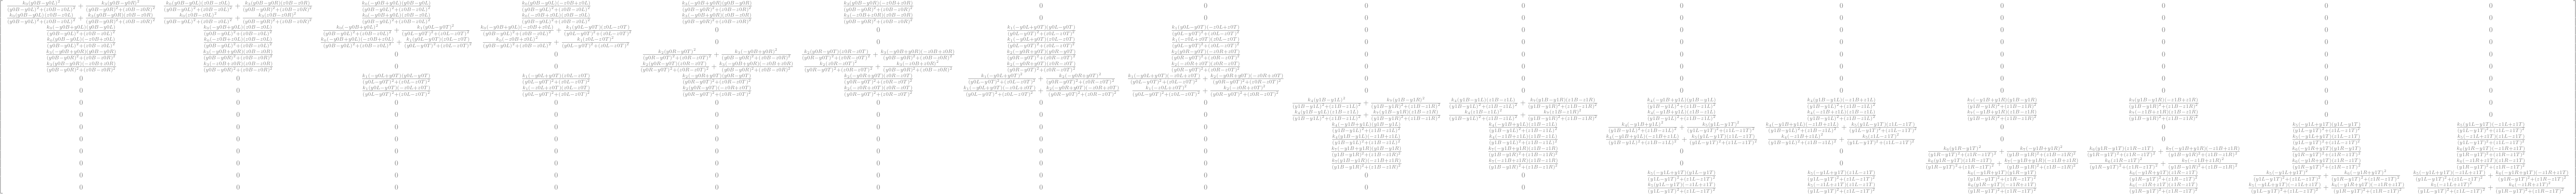

In [70]:
# ------------------------------------------------------------
# 8. Gradient and Hessian with respect to u
# ------------------------------------------------------------
grad_H = sp.Matrix([sp.diff(H, var) for var in u])
hess_H = sp.hessian(H, u)

# This should match C^T K C exactly in the linear case
# simplify takes too long to run in the Hamiltonian, so remove it for now
#hess_from_C = sp.simplify(C.T * K * C)
hess_from_C = C.T * K * C
print("The Hessian (using the C matrix):")
display(hess_from_C)

In [ ]:
# ------------------------------------------------------------
# 9. Maxwell-Calladine analysis
# ------------------------------------------------------------

Nc = C.shape[0]        # number of constraints
dN = C.shape[1]        # total DOFs = dim * N

Nrb = 3                # rigid body motions in 2D

rank_C = C.rank()

# BIG Q1: How can the structure move without stretching constraints (freely)? -> explained by MECHANISMS
# Number of mechanisms (nullspace of C)
M = dN - rank_C

# BIG Q2: How can forces exist without motion? -> explained by self-stress
# Number of states of self stress (nullspace of C^T)
S = Nc - rank_C

print("\n===========================")
print("Maxwell-Calladine Analysis")
print("=============================")

print("dN (total DOFs):", dN)
print("Nc (constraints):", Nc)
print("Rank(C):", rank_C)

print("\nMechanisms (M):", M)
print("States of self-stress (S):", S)

print("\nCheck: M - S =", M - S)
print("Expected:", dN - Nc)


Maxwell-Calladine Analysis
dN (total DOFs): 3
Nc (constraints): 13
Rank(C): 2

Mechanisms (M): 1
States of self-stress (S): 11

Check: M - S = -10
Expected: -10


In [36]:
# This block tells us whether the system is floppy, rigid, or overconstrained–and HOW
# BIG Q3: How many true deformation modes are there? -> answered by # of internal mechanisms
M_internal = M - Nrb

# INTERPRETATION:
# M_internal > 0 -> system is floppy
# M_internal = 0 -> system is rigid (isostatic)
# M_internal < 0 -> system is overconstrained (self-stress exists)

print("\nInternal mechanisms (excluding rigid body):", M_internal)

# motions that do not stretch any constraint
nullspace_C = C.nullspace()
print("\nNumber of basis vectors in nullspace:", len(nullspace_C))

# A mode is one way the structure can move without stretching any connections
for i, vec in enumerate(nullspace_C):
    print(f"\nMode {i}:")
    display(vec)

nullspace_CT = C.T.nullspace()
print("\nStates of self-stress:", len(nullspace_CT))


Internal mechanisms (excluding rigid body): -2

Number of basis vectors in nullspace: 1

Mode 0:


Matrix([
[pi**2*sin(2*pi*z1)*cos(2*pi*z1)],
[                              1],
[                              1]])


States of self-stress: 11



FREE CASE
l shape: (13, 1)
C shape: (13, 3)
K shape: (13, 13)
Hessian shape: (3, 3)

FREE CASE
C shape: (13, 3)
Rank(C): 2
Mechanisms M: 1
States of self-stress S: 11
Check M - S = -10
Expected     = -10

TOUCHING CASE
l shape: (13, 1)
C shape: (13, 3)
K shape: (13, 13)
Hessian shape: (3, 3)

TOUCHING CASE
C shape: (13, 3)
Rank(C): 2
Mechanisms M: 1
States of self-stress S: 11
Check M - S = -10
Expected     = -10

Sampled-grid minimum:
a_min = 0.0
b_min = -2.0
H_min = 39.125


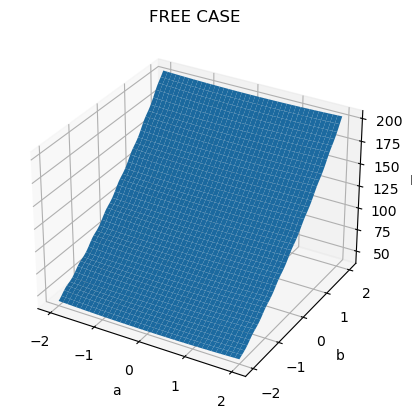

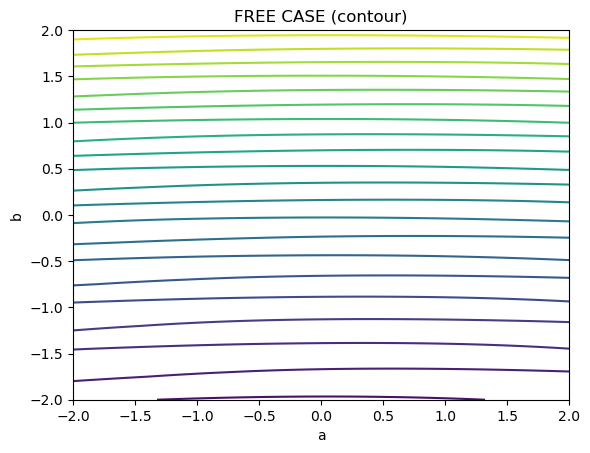

In [ ]:
# ============================================================
# UNIFIED RAMMs ANALYSIS TOOL — REDUCED-COORDINATE VERSION
# ============================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. REDUCED COORDINATES + PARAMETERS
# ============================================================

theta0, z0, z1 = sp.symbols('theta0 z0 z1', real=True)
q = sp.Matrix([theta0, z0, z1])

a0, b0 = sp.symbols('a0 b0', positive=True, real=True)
a1, b1 = sp.symbols('a1 b1', positive=True, real=True)
eps_bpg = sp.symbols('eps_bpg', real=True)

# ============================================================
# 1. NODE GEOMETRY p(q)
# ============================================================

def rot(theta):
    return sp.Matrix([
        [sp.cos(theta), -sp.sin(theta)],
        [sp.sin(theta),  sp.cos(theta)]
    ])

# bottom-tip anchored local coordinates
pB0_local = sp.Matrix([0, 0])
pL0_local = sp.Matrix([-a0, b0])
pR0_local = sp.Matrix([ a0, b0])
pT0_local = sp.Matrix([0, 2*b0])

pB1_local = sp.Matrix([0, 0])
pL1_local = sp.Matrix([-a1, b1])
pR1_local = sp.Matrix([ a1, b1])
pT1_local = sp.Matrix([0, 2*b1])

# global bottom-tip anchors
c0 = sp.Matrix([0, z0])
c1 = sp.Matrix([0, z1])

R0 = rot(theta0)
R1 = rot(theta0)   # change if unit 1 later gets its own angle

p0B = c0 + R0 * pB0_local
p0L = c0 + R0 * pL0_local
p0R = c0 + R0 * pR0_local
p0T = c0 + R0 * pT0_local

p1B = c1 + R1 * pB1_local
p1L = c1 + R1 * pL1_local
p1R = c1 + R1 * pR1_local
p1T = c1 + R1 * pT1_local

nodes = [p0B, p0L, p0R, p0T, p1B, p1L, p1R, p1T]

# node labels, for readability
# 0 = p0B, 1 = p0L, 2 = p0R, 3 = p0T
# 4 = p1B, 5 = p1L, 6 = p1R, 7 = p1T

# ============================================================
# 2. SHAPE CONSTRAINTS
# ============================================================

shape_bonds = [
    (0, 1),  # unit 0: bottom-left
    (1, 3),  # unit 0: left-top
    (3, 2),  # unit 0: top-right
    (2, 0),  # unit 0: right-bottom
    (4, 5),  # unit 1: bottom-left
    (5, 7),  # unit 1: left-top
    (7, 6),  # unit 1: top-right
    (6, 4),  # unit 1: right-bottom
    (0, 3),  # unit 0: bottom-top
    (4, 7),  # unit 1: bottom-top
]

def dist(pa, pb):
    d = pb - pa
    return sp.sqrt((d.T * d)[0])

# symbolic rest lengths
RL = sp.symbols(f'RL0:{len(shape_bonds)}', positive=True, real=True)

l_shape = sp.Matrix([
    dist(nodes[i], nodes[j]) - RL[k]
    for k, (i, j) in enumerate(shape_bonds)
])

# ============================================================
# 3. EXPLICIT CONTACT / KINEMATIC CONSTRAINTS
# ============================================================

l_constraint = sp.Matrix([
    theta0 - (sp.pi/4) * sp.sin(2 * sp.pi * z1)**2,
    z1 - (z0 - eps_bpg),
    z0 - z1
])

# full constraint vector
l = sp.Matrix.vstack(l_shape, l_constraint)

# compatibility = Jacobian wrt reduced coordinates
C = l.jacobian(q)

# stiffnesses: one per constraint
k_vals = sp.symbols(f'k0:{l.shape[0]}', positive=True, real=True)
K = sp.diag(*k_vals)

# ============================================================
# 4. SYSTEM BUILDER
# ============================================================

def build_system(param_subs, config_subs, label="System"):
    """
    Build l(q), C(q), K, and Hessian at a chosen configuration.
    
    param_subs  : geometry / stiffness / rest-length substitutions
    config_subs : values for q = [theta0, z0, z1]
    """
    subs_all = {}
    subs_all.update(param_subs)
    subs_all.update(config_subs)

    l_eval = sp.simplify(l.subs(subs_all))
    C_eval = sp.simplify(C.subs(subs_all))
    K_eval = sp.simplify(K.subs(subs_all))
    H_eval = sp.simplify(C_eval.T * K_eval * C_eval)

    print("\n====================")
    print(label)
    print("====================")
    print("l shape:", l_eval.shape)
    print("C shape:", C_eval.shape)
    print("K shape:", K_eval.shape)
    print("Hessian shape:", H_eval.shape)

    return l_eval, C_eval, K_eval, H_eval

# ============================================================
# 5. MAXWELL–CALLADINE ON REDUCED SYSTEM
# ============================================================

def analyze_system(C_mat, label="System"):
    """
    Maxwell–Calladine-style count for the reduced-coordinate system.
    Here DOFs = len(q), not 2N node displacements.
    """
    print("\n====================")
    print(label)
    print("====================")

    Nc = C_mat.shape[0]
    dq = C_mat.shape[1]
    rank = C_mat.rank()

    M = dq - rank
    S = Nc - rank

    print("C shape:", C_mat.shape)
    print("Rank(C):", rank)
    print("Mechanisms M:", M)
    print("States of self-stress S:", S)
    print("Check M - S =", M - S)
    print("Expected     =", dq - Nc)

# ============================================================
# 6. ENERGY IN q-SPACE
# ============================================================

def make_q(vals):
    """
    Convenience builder for reduced-coordinate vectors.

    vals = (theta0, z0, z1)
    """
    return sp.Matrix(vals)

# WARNING: takes a long time to run...
def plot_energy_landscape_q(l_expr, K_mat, q_base, q_dir1, q_dir2, subs_params, title="Energy"):
    """
    Plot H(q) over a 2D slice:
        q(a,b) = q_base + a*q_dir1 + b*q_dir2
    """
    a_vals = np.linspace(-2, 2, 81)
    b_vals = np.linspace(-2, 2, 81)

    A, B = np.meshgrid(a_vals, b_vals)
    H_grid = np.zeros_like(A, dtype=float)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            q_ab = q_base + A[i, j] * q_dir1 + B[i, j] * q_dir2

            subs_ab = dict(subs_params)
            subs_ab[theta0] = float(q_ab[0])
            subs_ab[z0] = float(q_ab[1])
            subs_ab[z1] = float(q_ab[2])

            l_val = l_expr.subs(subs_ab)
            H_val = sp.Rational(1, 2) * (l_val.T * K_mat.subs(subs_ab) * l_val)[0]
            H_grid[i, j] = float(H_val.evalf())

    min_idx = np.unravel_index(np.argmin(H_grid), H_grid.shape)

    print("\nSampled-grid minimum:")
    print("a_min =", A[min_idx])
    print("b_min =", B[min_idx])
    print("H_min =", H_grid[min_idx])

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A, B, H_grid)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('H')
    ax.set_title(title)
    plt.show()

    plt.figure()
    plt.contour(A, B, H_grid, levels=20)
    plt.title(title + " (contour)")
    plt.xlabel("a")
    plt.ylabel("b")
    plt.show()

def plot_energy_landscape_q_slice(l_expr, K_mat, q_base, q_dir1, q_dir2, subs_params, title="Energy"):
    """
    Plot H(q) over a 2D slice:
        q(a,b) = q_base + a*q_dir1 + b*q_dir2

    Faster version using lambdify.
    """
    a_vals = np.linspace(-2, 2, 81)
    b_vals = np.linspace(-2, 2, 81)

    A, B = np.meshgrid(a_vals, b_vals)
    H_grid = np.zeros_like(A, dtype=float)

    # First substitute all fixed parameters once
    l_num_expr = sp.simplify(l_expr.subs(subs_params))
    K_num_expr = sp.simplify(K_mat.subs(subs_params))

    # Build scalar symbolic energy once
    H_expr = sp.simplify(sp.Rational(1, 2) * (l_num_expr.T * K_num_expr * l_num_expr)[0])

    # Turn symbolic expression into a fast numeric function
    H_func = sp.lambdify((theta0, z0, z1), H_expr, modules="numpy")

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            q_ab = q_base + A[i, j] * q_dir1 + B[i, j] * q_dir2
            H_grid[i, j] = float(H_func(float(q_ab[0]), float(q_ab[1]), float(q_ab[2])))

    min_idx = np.unravel_index(np.argmin(H_grid), H_grid.shape)

    print("\nSampled-grid minimum:")
    print("a_min =", A[min_idx])
    print("b_min =", B[min_idx])
    print("H_min =", H_grid[min_idx])

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A, B, H_grid)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('H')
    ax.set_title(title)
    plt.show()

    plt.figure()
    plt.contour(A, B, H_grid, levels=20)
    plt.title(title + " (contour)")
    plt.xlabel("a")
    plt.ylabel("b")
    plt.show()

# ============================================================
# 7. EXAMPLE SUBSTITUTIONS
# ============================================================

# geometry parameters
param_subs = {
    a0: 8,  b0: 10,
    a1: 8,  b1: 10,
    eps_bpg: 0.5,
}

# compute rest lengths from the intended reference geometry
# choose a reference q where each unit is upright
ref_q = {
    theta0: 0,
    z0: 0,
    z1: 10,
}

for k, (i, j) in enumerate(shape_bonds):
    RL_ij = dist(nodes[i], nodes[j]).subs({**param_subs, **ref_q})
    param_subs[RL[k]] = sp.simplify(RL_ij)

# stiffnesses
for kv in k_vals:
    param_subs[kv] = 1

# two configurations
config_free = {
    theta0: 0.0,
    z0: 0.0,
    z1: 10.0,
}

config_touch = {
    theta0: 0.0,
    z0: 0.0,
    z1: 0.0,
}

# ============================================================
# 8. BUILD + ANALYZE
# ============================================================

l_free, C_free, K_free, Hess_free = build_system(param_subs, config_free, "FREE CASE")
analyze_system(C_free, "FREE CASE")

l_touch, C_touch, K_touch, Hess_touch = build_system(param_subs, config_touch, "TOUCHING CASE")
analyze_system(C_touch, "TOUCHING CASE")

# ============================================================
# 9. CHOOSE q-DIRECTIONS
# ============================================================

q_base = make_q((0.0, 0.0, 10.0))

# direction 1: change angle
q_dir1 = make_q((1.0, 0.0, 0.0))

# direction 2: relative vertical motion
q_dir2 = make_q((0.0, -1.0, 1.0))

# ============================================================
# 10. ENERGY LANDSCAPES
# ============================================================

plot_energy_landscape_q_slice(l, K, q_base, q_dir1, q_dir2, param_subs, "FREE CASE")


FREE CASE
C shape: (8, 16)
Rank(C): 8
Mechanisms M: 8
Internal mechanisms: 5
States of self-stress S: 0
Check M - S = 8
Expected     = 8

Hessian shape: (16, 16)

TOUCHING CASE
C shape: (12, 16)
Rank(C): 12
Mechanisms M: 4
Internal mechanisms: 1
States of self-stress S: 0
Check M - S = 4
Expected     = 4

Hessian shape: (16, 16)

Sampled-grid minimum:
a_min = 0.0
b_min = 0.0
H_min = 0.0


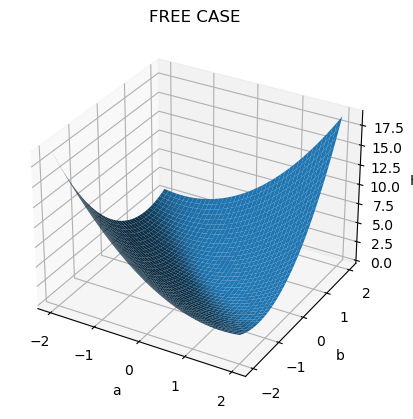

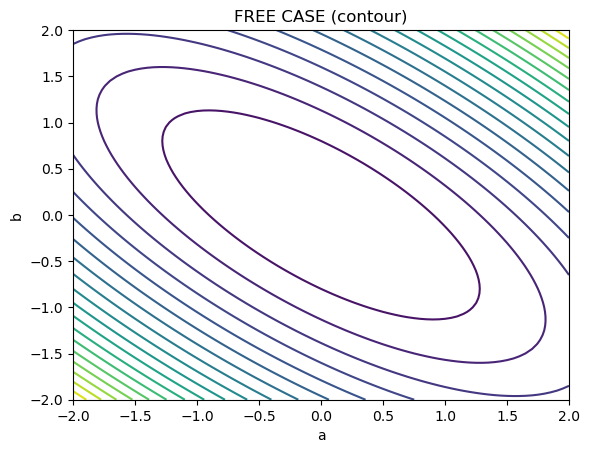


Sampled-grid minimum:
a_min = 0.0
b_min = 0.0
H_min = 0.0


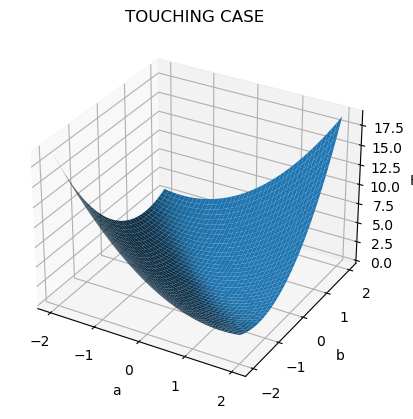

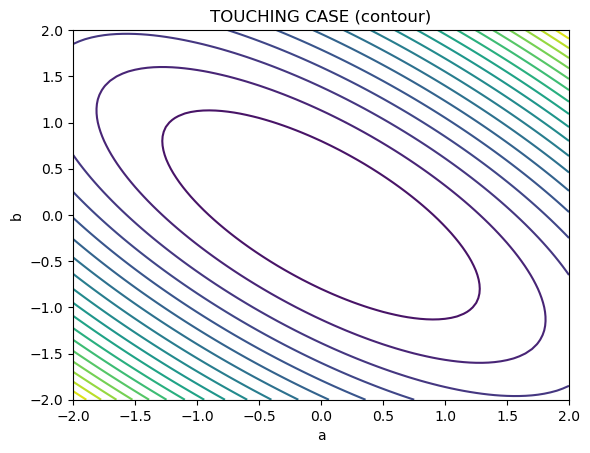

In [84]:
# ============================================================
# UNIFIED RAMMs ANALYSIS TOOL (ANNOTATED)
# ============================================================
#
# PURPOSE:
# This script lets you:
# 1. Build a constraint-based model of a RAMMs system
# 2. Analyze rigidity using Maxwell–Calladine
# 3. Compute the Hessian (stiffness matrix)
# 4. Visualize energy (Hamiltonian) over selected motion directions
#
# KEY IDEA:
# Everything flows from:
#     l = C u
#     H = 1/2 * l^T K l = 1/2 * u^T (C^T K C) u
#
# So:
# - C encodes geometry + constraints
# - K encodes stiffness
# - H encodes energy
# ============================================================

# ============================================================
# 1. SYSTEM BUILDER
# ============================================================

def build_system(geom_subs, add_contacts=False):
    """
    Build the compatibility matrix C and stiffness matrix K.

    INPUTS:
    - geom_subs: dictionary mapping symbolic node coordinates → numbers
        (this defines the geometry of the system)

    - add_contacts: whether to add contact constraints between units

    OUTPUTS:
    - C_full: compatibility matrix
        maps displacements u → constraint stretch l

    - K_full: diagonal stiffness matrix
        assigns stiffness to each constraint
    """

    # --------------------------------------------------------
    # Base system (bars / geometric constraints)
    # --------------------------------------------------------
    # Substitute numeric geometry into symbolic C
    C_base = C.subs(geom_subs)

    # Assign all stiffness values = 1 for now
    k_subs = {k: 1 for k in k_vals}
    K_base = K.subs(k_subs)

    # If no contact constraints, return base system
    if not add_contacts:
        return C_base, K_base

    # --------------------------------------------------------
    # Contact constraints (coincident nodes)
    # --------------------------------------------------------
    # These enforce: node_a displacement == node_b displacement
    #
    # IMPORTANT:
    # These are NOT distance constraints — they are equality constraints

    def contact_row(node_a, node_b, comp):
        """
        Create one row enforcing:
            u_b(component) - u_a(component) = 0

        comp = 0 → y-direction
        comp = 1 → z-direction
        """
        row = sp.zeros(1, 2*N)
        row[0, 2*node_a + comp] = -1
        row[0, 2*node_b + comp] =  1
        return row

    # Left and right node contacts
    contact_rows = [
        contact_row(1, 5, 0),
        contact_row(1, 5, 1),
        contact_row(2, 6, 0),
        contact_row(2, 6, 1),
    ]

    # Stack all contact rows into matrix
    C_contact = sp.Matrix.vstack(*contact_rows)

    # Combine base constraints + contact constraints
    C_full = sp.Matrix.vstack(C_base, C_contact)

    # --------------------------------------------------------
    # Build stiffness matrix for full system
    # --------------------------------------------------------
    # Add stiffness entries for contact constraints
    k_contact = sp.symbols('k_contact0:4')

    K_full = sp.diag(*list(K_base.diagonal()), *k_contact)

    # Set contact stiffness = 1 (same as bars)
    K_full = K_full.subs({k: 1 for k in k_contact})

    return C_full, K_full


# ============================================================
# 2. MAXWELL–CALLADINE + HESSIAN
# ============================================================

def analyze_system(C_mat, K_mat, label="System"):
    """
    Perform rigidity analysis using Maxwell–Calladine.

    Also compute Hessian:
        H'' = C^T K C

    OUTPUT:
    - prints system properties
    - returns Hessian
    """

    print("\n====================")
    print(label)
    print("====================")

    Nc = C_mat.shape[0]   # number of constraints
    dN = C_mat.shape[1]   # number of DOFs
    rank = C_mat.rank()   # number of independent constraints

    # Rigid body modes in 2D
    Nrb = 3

    # Maxwell–Calladine
    M = dN - rank               # total mechanisms
    S = Nc - rank               # self-stress states
    M_internal = M - Nrb        # remove rigid-body motion

    print("C shape:", C_mat.shape)
    print("Rank(C):", rank)
    print("Mechanisms M:", M)
    print("Internal mechanisms:", M_internal)
    print("States of self-stress S:", S)
    print("Check M - S =", M - S)
    print("Expected     =", dN - Nc)

    # Hessian = stiffness matrix in displacement space
    Hess = C_mat.T * K_mat * C_mat

    print("\nHessian shape:", Hess.shape)

    return Hess


# ============================================================
# 3. DISPLACEMENT BUILDER
# ============================================================

def make_u(vals):
    """
    Build displacement vector u.

    INPUT:
    vals = {
        node_index: (uy, uz),
        ...
    }

    OUTPUT:
    u = [u0y, u0z, u1y, u1z, ...]^T
    """
    u_test = []
    for i in range(N):
        uy, uz = vals.get(i, (0, 0))
        u_test.extend([uy, uz])
    return sp.Matrix(u_test)


# ============================================================
# 4. ENERGY LANDSCAPE (Hamiltonian slice)
# ============================================================

def plot_energy_landscape(C_mat, K_mat, u_dir1, u_dir2, title="Energy"):
    """
    Visualize H(u) over a 2D slice of motion space.

    IMPORTANT:
    Full system is high-dimensional → cannot plot directly.

    So we define:
        u(a,b) = a*u_dir1 + b*u_dir2

    Then compute:
        H(a,b)

    This shows how energy changes along those two directions.
    """

    # Compute Hamiltonian for a given displacement
    def H_eval(u_vec):
        l_vec = C_mat * u_vec
        H_val = sp.Rational(1, 2) * (l_vec.T * K_mat * l_vec)[0]
        return float(H_val.evalf())

    def u_ab(a, b):
        return a * u_dir1 + b * u_dir2

    # Sampling grid
    a_vals = np.linspace(-2, 2, 81)
    b_vals = np.linspace(-2, 2, 81)

    A, B = np.meshgrid(a_vals, b_vals)
    H_grid = np.zeros_like(A)

    # Evaluate energy over grid
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            H_grid[i, j] = H_eval(u_ab(A[i, j], B[i, j]))

    # Find minimum in sampled region
    min_idx = np.unravel_index(np.argmin(H_grid), H_grid.shape)

    print("\nSampled-grid minimum:")
    print("a_min =", A[min_idx])
    print("b_min =", B[min_idx])
    print("H_min =", H_grid[min_idx])

    # 3D surface plot
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A, B, H_grid)

    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('H')
    ax.set_title(title)

    plt.show()

    # Contour plot (often easier to interpret)
    plt.figure()
    plt.contour(A, B, H_grid, levels=20)
    plt.title(title + " (contour)")
    plt.xlabel("a")
    plt.ylabel("b")
    plt.show()


# ============================================================
# 5. CONFIGURATION (EDIT HERE)
# ============================================================

# Free system (units separated)
geom_free = {
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R: 8,   z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 10,
    y1L: -8,  z1L: 20,
    y1R: 8,   z1R: 20,
    y1T: 0,   z1T: 30,
}

# Touching system (side nodes coincide)
geom_touch = {
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R: 8,   z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 0,
    y1L: -8,  z1L: 10,
    y1R: 8,   z1R: 10,
    y1T: 0,   z1T: 20,
}


# ============================================================
# 6. BUILD + ANALYZE BOTH SYSTEMS
# ============================================================

C_free, K_free = build_system(geom_free, add_contacts=False)
H_free = analyze_system(C_free, K_free, "FREE CASE")

C_touch, K_touch = build_system(geom_touch, add_contacts=True)
H_touch = analyze_system(C_touch, K_touch, "TOUCHING CASE")


# ============================================================
# 7. CHOOSE MOTION DIRECTIONS (EDIT THESE)
# ============================================================

# These define what "slice" of motion space you visualize

u_dir1 = make_u({
    3: (0, 1),
    7: (0, 1),
})

u_dir2 = make_u({
    1: (-1, 0),
    2: ( 1, 0),
    5: (-1, 0),
    6: ( 1, 0),
})


# ============================================================
# 8. COMPARE ENERGY LANDSCAPES
# ============================================================

plot_energy_landscape(C_free, K_free, u_dir1, u_dir2, "FREE CASE")
plot_energy_landscape(C_touch, K_touch, u_dir1, u_dir2, "TOUCHING CASE")